1.Build a simple autoencoder in Python using Keras to compress and reconstruct 28x28 grayscale images from the Fashion MNIST dataset. Train for 5 epochs and display one original and its reconstructed image side by side.

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 3us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0521 - val_loss: 0.0274
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0230 - val_loss: 0.0198
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0178 - val_loss: 0.0162
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0149 - val_loss: 0.0139
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0131 - val_loss: 0.0126
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


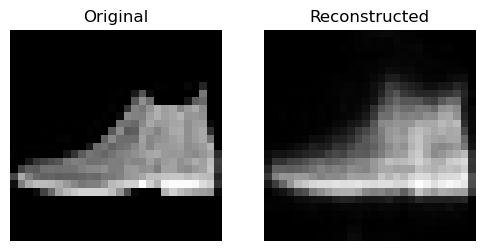

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape

(x_train, _), (x_test, _) = fashion_mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

input_img = Input(shape=(28, 28))

x = Flatten()(input_img)
encoded = Dense(64, activation='relu')(x)
x = Dense(784, activation='sigmoid')(encoded)
decoded = Reshape((28, 28))(x)

autoencoder = Model(input_img, decoded)

autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.fit(
    x_train,
    x_train,
    epochs=5,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)

reconstructed = autoencoder.predict(x_test[:1])

plt.figure(figsize=(6, 3))

plt.subplot(1, 2, 1)
plt.imshow(x_test[0], cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(reconstructed[0], cmap='gray')
plt.title("Reconstructed")
plt.axis('off')

plt.show()

2.Modify your autoencoder's loss function to use Binary Crossentropy (BCE) instead of Mean Squared Error (MSE), then compare the reconstruction quality visually for 3 test images.<br><br><em><strong>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


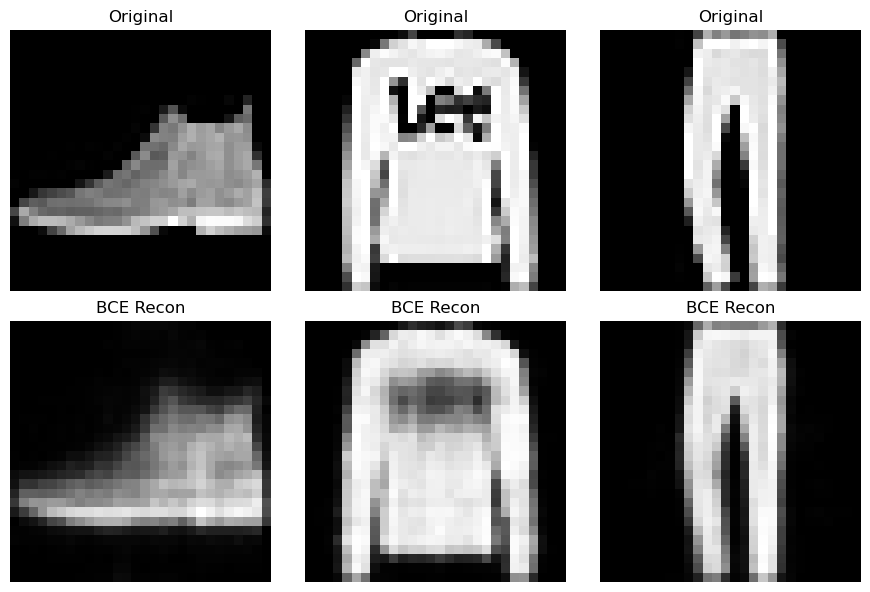

In [ ]:
reconstructed = autoencoder.predict(x_test[:3])

plt.figure(figsize=(9, 6))

for i in range(3):
    plt.subplot(2, 3, i + 1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title("Original")
    plt.axis('off')

    plt.subplot(2, 3, i + 4)
    plt.imshow(reconstructed[i], cmap='gray')
    plt.title("BCE Recon")
    plt.axis('off')

plt.tight_layout()
plt.show()

3.Use your trained autoencoder to denoise images: add random noise to 10 Fashion MNIST test images, pass them through the autoencoder, and display the noisy and denoised outputs together.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


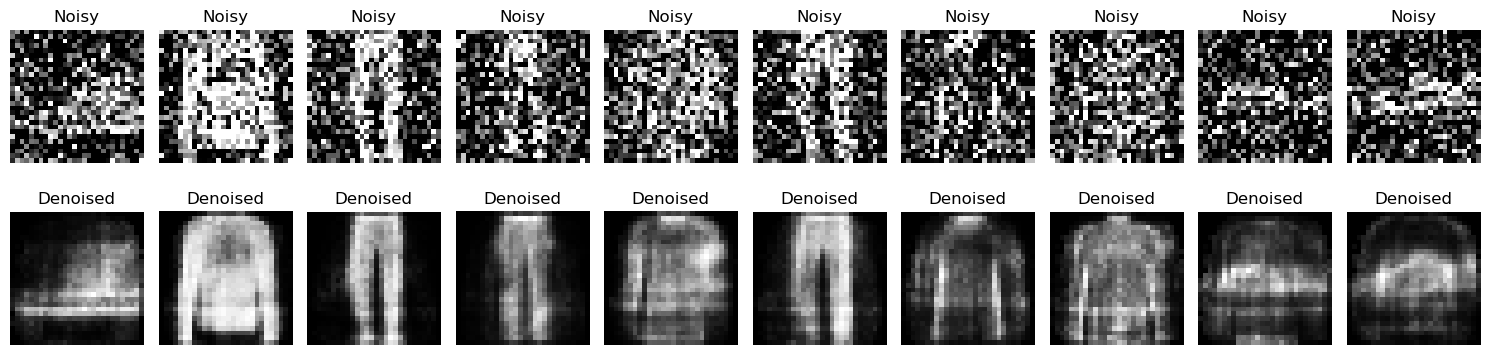

In [ ]:
noise_factor = 0.5

x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)

x_test_noisy = np.clip(x_test_noisy, 0., 1.)

denoised_images = autoencoder.predict(x_test_noisy[:10])

plt.figure(figsize=(15, 4))

for i in range(10):
    plt.subplot(2, 10, i + 1)
    plt.imshow(x_test_noisy[i], cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    plt.subplot(2, 10, i + 11)
    plt.imshow(denoised_images[i], cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

plt.tight_layout()
plt.show()

4.Build a Variational Autoencoder (VAE) using Keras for the Fashion MNIST dataset. After training, sample 5 random points from the latent space and generate new images from these points.<br><br><em><strong>

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - kl_loss: 3.2001 - loss: 35.3915 - reconstruction_loss: 32.1915
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - kl_loss: 3.5686 - loss: 37.0487 - reconstruction_loss: 33.4802
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 3.4820 - loss: 38.2526 - reconstruction_loss: 34.7707
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 3.5839 - loss: 36.4830 - reconstruction_loss: 32.8991
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - kl_loss: 3.6939 - loss: 38.3959 - reconstruction_loss: 34.7020
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - kl_loss: 3.7394 - loss: 38.0076 - reconstruction_loss: 34.2681
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - kl_loss: 3.6468 - loss: 35.5956 - reconstruction_loss: 31.9489
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 3.7725 - loss: 36.3879 - reconstruction_loss: 32.6154
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - kl_loss: 3

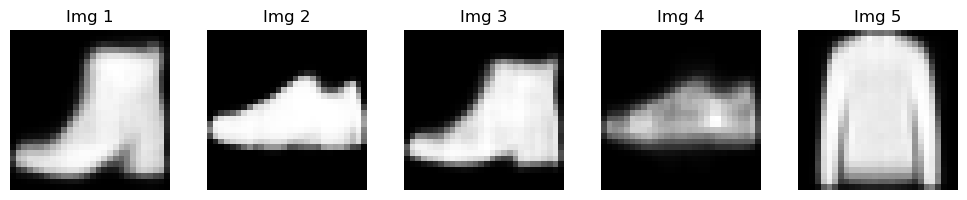

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model

x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

latent_dim = 2

encoder_inputs = layers.Input(shape=(784,))
x = layers.Dense(256, activation="relu")(encoder_inputs)

z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)

class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]

        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = Sampling()([z_mean, z_log_var])

encoder = Model(
    encoder_inputs,
    [z_mean, z_log_var, z],
    name="encoder"
)

latent_inputs = layers.Input(shape=(latent_dim,))
x = layers.Dense(256, activation="relu")(latent_inputs)
decoder_outputs = layers.Dense(784, activation="sigmoid")(x)

decoder = Model(
    latent_inputs,
    decoder_outputs,
    name="decoder"
)

class VAE(Model):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)

            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.keras.losses.binary_crossentropy(
                        data, reconstruction
                    ),
                    axis=-1
                )
            )

            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var
                    - tf.square(z_mean)
                    - tf.exp(z_log_var),
                    axis=1
                )
            )

            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(
            total_loss,
            self.trainable_weights
        )
        self.optimizer.apply_gradients(
            zip(grads, self.trainable_weights)
        )

        return {
            "loss": total_loss,
            "reconstruction_loss": reconstruction_loss,
            "kl_loss": kl_loss,
        }

vae = VAE(encoder, decoder)

vae.compile(optimizer="adam")

# Train VAE
vae.fit(
    x_train,
    epochs=10,
    batch_size=128
)

random_latent_vectors = np.random.normal(
    size=(5, latent_dim)
)

generated_images = decoder.predict(
    random_latent_vectors
)

generated_images = generated_images.reshape(
    5, 28, 28
)

# Display generated images
plt.figure(figsize=(10, 2))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(generated_images[i], cmap="gray")
    plt.axis("off")
    plt.title(f"Img {i+1}")

plt.tight_layout()
plt.show()

5.Use ChatGPT to explain in your own words what KL-divergence loss does in a VAE and why it is needed. Paste your prompt and ChatGPT's response as your answer.

ChatGPT Response:

KL-divergence (Kullback-Leibler divergence) loss measures how different the latent space learned by the encoder is from a standard normal distribution. It acts as a regularization term that encourages the latent variables to follow a smooth and continuous distribution.

This is important because a VAE generates new data by sampling random points from the latent space. If the latent space is not organized properly, random samples may produce unrealistic outputs. KL-divergence helps keep the latent space structured, allowing the model to generate meaningful and diverse new images. It also prevents the model from simply memorizing the training data.

In My Own Words:

KL-divergence loss helps the VAE keep its latent space organized by making it similar to a normal distribution. This allows the model to generate new and realistic images when random points are sampled from the latent space. Without KL-divergence, the model might memorize the training data and struggle to create meaningful new images. Therefore, KL-divergence is needed to improve generalization and image generation quality.
